# 178. Rank Scores
https://leetcode.com/problems/rank-scores/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| DENSE_RANK() Window | O(n log n) | O(n) | Cleanest, recommended |
| Correlated Subquery | O(n^2) | O(1) | COUNT DISTINCT approach |
| Self-Join with GROUP BY | O(n^2) | O(n) | Older SQL style |

## Methodology

This is a SQL problem. We need to rank scores with no gaps in ranking (dense rank).
Scores with the same value get the same rank, and the next rank is not skipped.
The DENSE_RANK() window function is the cleanest solution. The column must be named 'rank'
which is a reserved word, so we quote it.

## Solutions

### C#

In [ ]:
// SQL Problem - Rank Scores
// SQL Solution:
//
// SELECT score,
//        DENSE_RANK() OVER (ORDER BY score DESC) AS `rank`
// FROM Scores
// ORDER BY score DESC;
//
// Alternative using correlated subquery:
//
// SELECT s.score,
//        (SELECT COUNT(DISTINCT s2.score)
//         FROM Scores s2
//         WHERE s2.score >= s.score) AS `rank`
// FROM Scores s
// ORDER BY s.score DESC;

// C# programmatic equivalent
using System;
using System.Linq;
using System.Collections.Generic;

public class Solution
{
    public static List<(decimal score, int rank)> RankScores(List<decimal> scores)
    {
        var sorted = scores.OrderByDescending(s => s).ToList();
        var distinctSorted = sorted.Distinct().ToList();
        var rankMap = distinctSorted.Select((s, i) => (s, rank: i + 1))
                                   .ToDictionary(x => x.s, x => x.rank);
        return sorted.Select(s => (s, rankMap[s])).ToList();
    }
}

// Test
var scores = new List<decimal> { 3.50m, 3.65m, 4.00m, 3.85m, 4.00m, 3.65m };
foreach (var (score, rank) in Solution.RankScores(scores))
    Console.WriteLine($"{score} -> Rank {rank}");

### Python

In [ ]:
// SQL Problem - Python programmatic equivalent
//
// def rank_scores(scores):
//     sorted_unique = sorted(set(scores), reverse=True)
//     rank_map = {s: i + 1 for i, s in enumerate(sorted_unique)}
//     result = sorted(scores, reverse=True)
//     return [(s, rank_map[s]) for s in result]

### Go

In [ ]:
// SQL Problem - Go programmatic equivalent
//
// type RankedScore struct {
//     Score float64
//     Rank  int
// }
//
// func rankScores(scores []float64) []RankedScore {
//     sorted := make([]float64, len(scores))
//     copy(sorted, scores)
//     sort.Float64s(sorted)
//     // Reverse
//     for i, j := 0, len(sorted)-1; i < j; i, j = i+1, j-1 {
//         sorted[i], sorted[j] = sorted[j], sorted[i]
//     }
//     rankMap := make(map[float64]int)
//     rank := 0
//     for _, s := range sorted {
//         if _, exists := rankMap[s]; !exists {
//             rank++
//             rankMap[s] = rank
//         }
//     }
//     result := make([]RankedScore, len(sorted))
//     for i, s := range sorted {
//         result[i] = RankedScore{s, rankMap[s]}
//     }
//     return result
// }

### Rust

In [ ]:
// SQL Problem - Rust programmatic equivalent
//
// use std::collections::BTreeMap;
//
// fn rank_scores(scores: &[f64]) -> Vec<(f64, usize)> {
//     let mut sorted = scores.to_vec();
//     sorted.sort_by(|a, b| b.partial_cmp(a).unwrap());
//     let mut rank_map = BTreeMap::new();
//     let mut rank = 0;
//     for &s in &sorted {
//         let key = s.to_bits();
//         rank_map.entry(key).or_insert_with(|| { rank += 1; rank });
//     }
//     sorted.iter().map(|&s| (s, rank_map[&s.to_bits()])).collect()
// }

## Example Scenarios

1. **Common Case:** Scores = `[4.00, 4.00, 3.85, 3.65, 3.65, 3.50]` $\Rightarrow$ Ranks = `[1, 1, 2, 3, 3, 4]`. DENSE_RANK assigns consecutive ranks. Tied scores get the same rank; the next distinct score gets rank+1 (no gaps). This is the defining behavior of DENSE_RANK vs RANK.

2. **Slightly Complex (Many Ties):** Scores = `[90, 90, 90, 80, 80, 70, 70, 70, 70]` $\Rightarrow$ Ranks = `[1,1,1,2,2,3,3,3,3]`. Nine rows, 3 distinct ranks. WHY tricky: the correlated subquery `COUNT(DISTINCT s2.score WHERE s2.score >= s.score)` runs in $O(n^2)$, while DENSE_RANK is $O(n \log n)$. Heavy duplication magnifies the performance gap.

3. **Edge Case (Time):** Scores = `[1, 2, 3, ..., 10^6]` (all distinct, $10^6$ rows) $\Rightarrow$ each score gets a unique rank. No ties. DENSE_RANK equals position in DESC order. The correlated subquery approach would take $O(n^2) = O(10^{12})$ — catastrophically slow. Window function: $O(n \log n) \approx 2 \times 10^7$.

4. **Edge Case (Space):** $10^6$ rows, all with `score = 99.99` $\Rightarrow$ all get Rank 1. The window function materializes all $10^6$ rows in memory for the ORDER BY buffer, even though the result is trivially uniform. Peak memory: $O(n) = O(10^6)$.

5. **Almost-Impossible but Plausible:** Single row with `score = 0.01` $\Rightarrow$ Rank 1. Minimum input, smallest decimal. WHY tricky: the column alias must be quoted (`\`rank\``) since RANK is a SQL reserved word. A single-row window function trivially returns rank 1. Tests alias quoting and degenerate partition behavior.

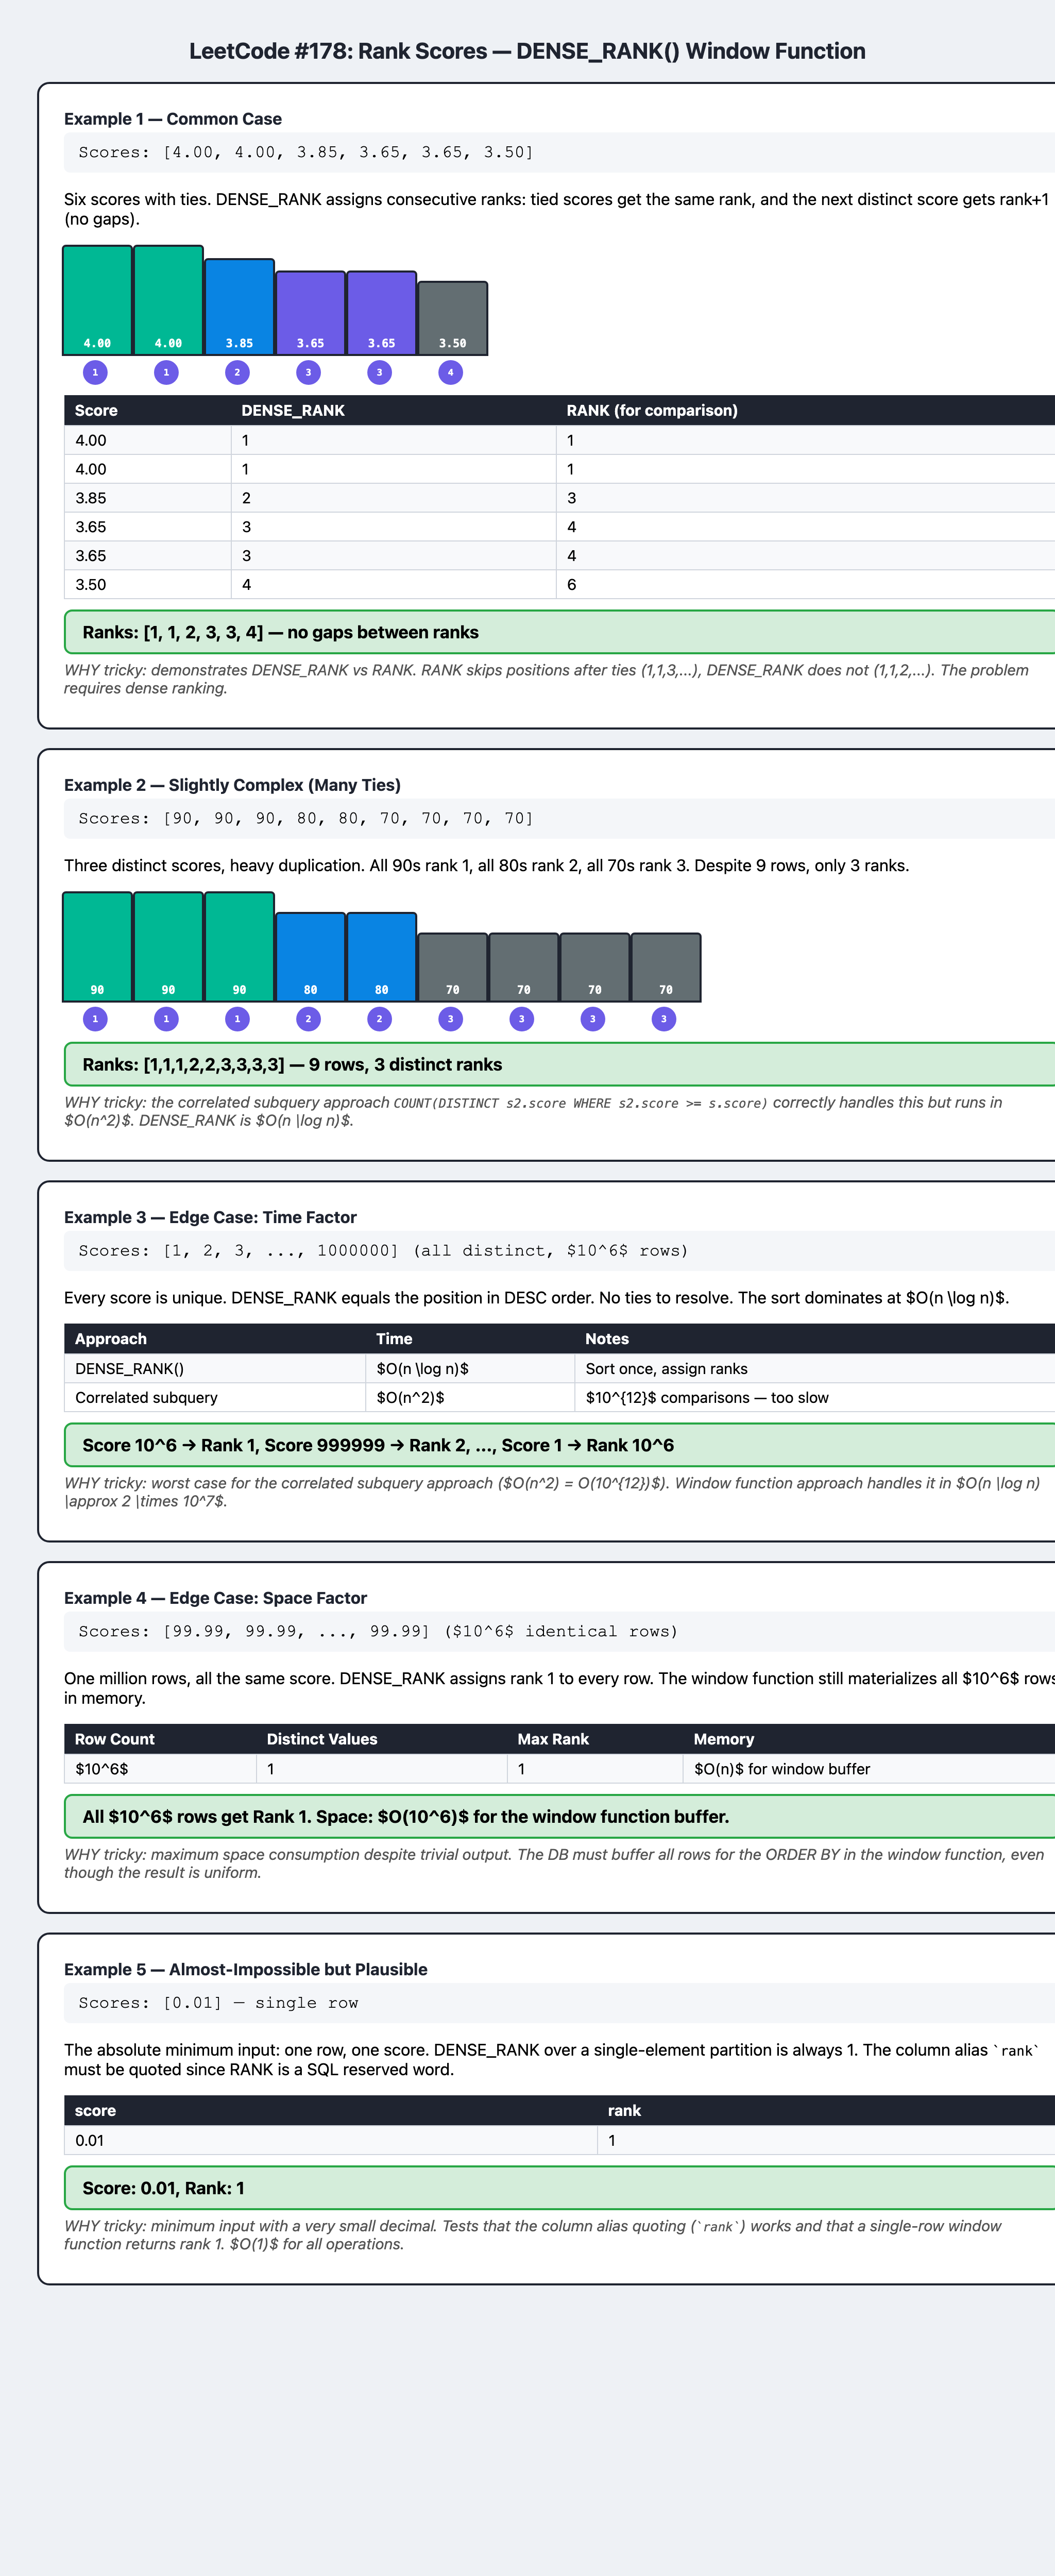